# wsssss introduction

This notebook will show some of the possibilities of `wsssss`. The documentation is available [here.](https://wsssss.readthedocs.io/latest/wsssss.html)

First we create a grid of MESA inlists, then run that grid with MESA and gyre. We first ensure that either the `MESA_DIR` environment variable is set or that we pass `mesa_dir` to `MesaGrid`, as it needs to know which version of MESA to create a grid for. We also tell `MesaGrid` to copy the basic files and folders needed for MESA (rn, re, mk, etc.). Next we set some inputs for the grid. We create a grid with 2 initial masses and 2 different overshooting, resulting in 4 sets of inlists.

In [1]:
import os

wsssss_dir = "/home/walter/Github/wsssss"
if 'MESA_DIR' not in os.environ.keys():
    os.environ['MESA_DIR'] = '/home/walter/Software/MESA/mesa-24.08.1'
mesa_dir = os.environ['MESA_DIR']


In [2]:
from wsssss.inlists import create_grid as cg

# If mesa_dir is not set it will use the MESA_DIR environment variable
grid = cg.MesaGrid(mesa_dir=mesa_dir, add_base_workdir=True)

grid.star_job['history_columns_file'] = 'history_test.list'
# Tell MesaGrid where the file is located:
grid.add_file(os.path.join(f'{wsssss_dir}/tests/make_data', grid.star_job['history_columns_file']))

grid.star_job['pgstar_flag'] = False
grid.star_job['create_pre_main_sequence_model'] = False

grid.kap['use_Type2_opacities'] = True
grid.kap['Zbase'] = 0.02

grid.controls['initial_mass'] = [1, 2]
grid.controls['initial_z'] = 0.02
grid.controls['max_model_number'] = 10
grid.controls['mesh_delta_coeff'] = 5

grid.controls['history_interval'] = 1
grid.controls['photo_interval'] = 8

grid.controls['write_profiles_flag'] = True
grid.controls['profile_interval'] = 9
grid.controls['write_pulse_data_with_profile'] = True
grid.controls['pulse_data_format'] = 'GYRE'

grid.controls[f'{cg.non_mesa_key_start}group_unpack'].append([{'overshoot_scheme(1)': 'exponential',
                                                               'overshoot_zone_type(1)': 'nonburn',
                                                               'overshoot_zone_loc(1)': 'shell',
                                                               'overshoot_bdy_loc(1)': 'bottom',
                                                               'overshoot_f(1)': 0.02,
                                                               'overshoot_f0(1)': 0.001},
                                                              {'overshoot_scheme(1)': 'exponential',
                                                               'overshoot_zone_type(1)': 'nonburn',
                                                               'overshoot_zone_loc(1)': 'shell',
                                                               'overshoot_bdy_loc(1)': 'bottom',
                                                               'overshoot_f(1)': 0.03,
                                                               'overshoot_f0(1)': 0.01}])


def name_function(unpacked):
    return f'm{unpacked["controls"]["initial_mass"]:.3f}_fOV{unpacked["controls"]["overshoot_f(1)"]:.3f}'


grid.set_name_function(name_function)

# If we want, we can apply an arbritraty function on each unpacked inlist with grid.set_inlist_finalize_function

def finalize_function(unpacked):
    if unpacked["controls"]['overshoot_f(1)'] == 0.03:
        unpacked["controls"]["overshoot_D_min"] = 1e-2    
    # We could also set the history file output name to something other than the default:
    # unpacked["controls"]["star_history_name"] = f'm{unpacked["controls"]["initial_mass"]:.3f}_fOV{unpacked["controls"]["overshoot_f(1)"]:.3f}.data'
    return unpacked

grid.set_inlist_finalize_function(finalize_function)

In [3]:
grid.unpack_inlists()

for i, inlist in enumerate(grid.unpacked):
    print(f'{i:04}')
    for namelist in inlist.keys():
        if isinstance(namelist, str):
            print(f'    {namelist}')
        for key, value in inlist[namelist].items():
            if not isinstance(value, dict):
                if not key.startswith(cg.non_mesa_key_start):
                    print(f'        {key}: {value}')
            else:
                print(f'        {key}:')
                for kkey, vvalue in value.items():
                    if not key.startswith(cg.non_mesa_key_start):
                        print(f'            {kkey}: {vvalue}')
    print()


0000
    inlist
        star_job:
            read_extra_star_job_inlist(5): True
            extra_star_job_inlist_name(5): inlist_project
        eos:
            read_extra_eos_inlist(5): True
            extra_eos_inlist_name(5): inlist_project
        kap:
            read_extra_kap_inlist(5): True
            extra_kap_inlist_name(5): inlist_project
        controls:
            read_extra_controls_inlist(5): True
            extra_controls_inlist_name(5): inlist_project
        pgstar:
            read_extra_pgstar_inlist(5): True
            extra_pgstar_inlist_name(5): inlist_project
    star_job
        history_columns_file: history_test.list
        pgstar_flag: False
        create_pre_main_sequence_model: False
    eos
    kap
        use_Type2_opacities: True
        Zbase: 0.02
    controls
        initial_mass: 1
        initial_z: 0.02
        max_model_number: 10
        mesh_delta_coeff: 5
        history_interval: 1
        photo_interval: 8
        write_profiles_f

In [4]:
grid_dir = os.path.abspath('example_wsssss')
grid.create_grid(grid_dir, rm_dir=False)

Cannot copy calling file /tmp/ipykernel_409779/2927543967.py to grid directory /home/walter/Github/wsssss/examples/example_wsssss.


In [5]:
os.listdir(grid_dir)

['m2.000_fOV0.020',
 'star',
 'm1.000_fOV0.020',
 'out_m2.000_fOV0.030',
 'm1.000_fOV0.030',
 'out_m1.000_fOV0.030',
 'out_m1.000_fOV0.020',
 'out_m2.000_fOV0.020',
 'm2.000_fOV0.030']

# Run `mesa-go`

First we compile `star` and copy it to the grid directory as we will copy it instead of compile it for each run of MESA. Next, run `mesa-go` ([docs](https://wsssss.readthedocs.io/latest/cmd.html#mesa-grid-overseer)), the MESA grid runner. We tell it that each run has a non-default name with `--sub-dirs m*`, and that before starting MESA to run `cp ../star ./` to copy the `star` executable we created earlier, and after running MESA to run the `gyre-driver` ([docs](https://wsssss.readthedocs.io/latest/cmd.html#gyre-driver)) on all the profiles in LOGS and to be lenient with which version of gyre is used.
```
cd /path/to/example_wsssss
cd m1.000_fOV0.020; ./mk; cp star ../; cd ..
mesa-go --sub-dirs m* --cmd-pre-each 'cp ../star ./' --cmd-post-each 'gyre-driver 01 MESA LOGS/*.GYRE --lenient'
check-grid --no-slurm --list-all
```
Once `mesa-go` is finished running we check if the grid ran successfully with `check-grid` ([docs](https://wsssss.readthedocs.io/latest/cmd.html#mesa-grid-check)). This should show the following:
```

  termination_code                   count
--------------------------------------------
max_model_number                           4
--------------------------------------------
m1.000_fOV0.021    pre-CHeX       9 max_model_number
m1.000_fOV0.030    pre-CHeX       9 max_model_number
m2.000_fOV0.021    pre-CHeX       9 max_model_number
m2.000_fOV0.030    pre-CHeX       9 max_model_number
--------------------------------------------
```


# Inlists

We can also evaluate an inlist and see which options it sets as well as compare different inlists. We also see that `overshoot_d_min` is not set in `m1.000_fOV0.020/inlist` but is set to 0.01 in `m1.000_fOV0.030/inlist` as expected from `grid.set_inlist_finalize_function`.

In [6]:
from wsssss.inlists import inlists as inl
inl.evaluate_inlist(f'{grid_dir}/m1.000_fOV0.020/inlist')

{'star_job': {'history_columns_file': 'history_test.list',
  'pgstar_flag': False,
  'create_pre_main_sequence_model': False},
 'eos': {},
 'kap': {'use_type2_opacities': True, 'zbase': 0.02},
 'controls': {'initial_mass': 1,
  'initial_z': 0.02,
  'max_model_number': 10,
  'mesh_delta_coeff': 5,
  'history_interval': 1,
  'photo_interval': 8,
  'write_profiles_flag': True,
  'profile_interval': 9,
  'write_pulse_data_with_profile': True,
  'pulse_data_format': 'GYRE',
  'overshoot_scheme(1)': 'exponential',
  'overshoot_zone_type(1)': 'nonburn',
  'overshoot_zone_loc(1)': 'shell',
  'overshoot_bdy_loc(1)': 'bottom',
  'overshoot_f(1)': 0.02,
  'overshoot_f0(1)': 0.001},
 'pgstar': {}}

In [7]:
inl.compare_inlist(f'{grid_dir}/m1.000_fOV0.020/inlist', f'{grid_dir}/m1.000_fOV0.030/inlist')

left : /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/inlist
right: /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.030/inlist

####### star_job differences #######

####### controls differences #######
overshoot_f(1): (0.02, 0.03)
overshoot_f0(1): (0.001, 0.01)
overshoot_d_min: (None, 0.01)


However, comparing MESA version strings should be done carefully:

In [8]:
print(inl.compare_version('11701', 'r24.03.1', '<'), '11701' < 'r24.03.1')
print(inl.compare_version('11701', '8118', '<'), '11701' < '8118')

True True
False True


In [9]:
inl.get_mesa_version(mesa_dir)

'r24.08.1'

# MESA histories and profiles

`wsssss` can also read MESA histories and profiles, as well as gyre summaries and mode files.

In [10]:
from wsssss import load_data as ld
import numpy as np

hist = ld.History(f'{grid_dir}/m1.000_fOV0.020/LOGS/history.data')
print(hist.columns)

['model_number', 'elapsed_time', 'star_age', 'star_mass', 'effective_T', 'photosphere_L', 'photosphere_r', 'luminosity', 'radius', 'gravity', 'center_T', 'center_Rho', 'center_P', 'center_degeneracy', 'center_mu', 'center_ye', 'center_h1', 'center_he3', 'center_he4', 'center_c12', 'center_n14', 'center_o16', 'center_ne20', 'center_mg24', 'surface_h1', 'surface_he3', 'surface_he4', 'surface_c12', 'surface_n14', 'surface_o16', 'surface_ne20', 'surface_mg24', 'mass_conv_core', 'he_core_mass', 'he_core_radius', 'co_core_mass', 'co_core_radius', 'log_LH', 'log_LHe', 'log_LZ', 'log_extra_L', 'log_Lneu', 'log_abs_Lgrav', 'pp', 'cno', 'tri_alpha', 'c_alpha', 'n_alpha', 'o_alpha', 'delta_nu', 'delta_Pg', 'nu_max', 'log_L', 'mix_type_1', 'mix_qtop_1', 'mix_type_2', 'mix_qtop_2', 'mix_type_3', 'mix_qtop_3', 'mix_type_4', 'mix_qtop_4', 'mix_type_5', 'mix_qtop_5', 'mix_type_6', 'mix_qtop_6', 'mix_type_7', 'mix_qtop_7', 'mix_type_8', 'mix_qtop_8', 'mix_type_9', 'mix_qtop_9', 'mix_type_10', 'mix_qtop

If we don't need all these columns we can choose which columns to keep in `History` (or and data class in `load_data`) :

In [11]:
hist = ld.History(f'{grid_dir}/m1.000_fOV0.020/LOGS/history.data', keep_columns=['model_number', 'star_age', 'effective_T', 'luminosity', 'nu_max', 'delta_nu', 'delta_Pg'])
print(hist.columns)

['model_number', 'star_age', 'effective_T', 'luminosity', 'nu_max', 'delta_nu', 'delta_Pg']


We can access the data in two ways, through attributes of `hist.data` or through the `hist.get` method:

In [12]:
hist.data.star_age
hist.get('star_age')
np.all(hist.get('star_age') == hist.data.star_age)

True

We can also index directly on `hist`, this will return a new `History` with a correctly set profile index, containing only profiles in the new `History` file.

In [13]:
print(len(hist))
print(hist.data)
print(hist.index)

10
[( 1,  100000.    , 5616.90892797, 0.70925563, 168.08043363, 0., 3945.14980227)
 ( 2,  220000.    , 5614.14501653, 0.70804627, 168.05210824, 0., 3945.08631765)
 ( 3,  364000.    , 5604.89019466, 0.70420514, 167.92708726, 0., 3943.76604529)
 ( 4,  536800.    , 5580.62037896, 0.69460378, 167.59231705, 0., 3938.01161344)
 ( 5,  744160.    , 5575.69560644, 0.6946222 , 167.152432  , 0., 3925.75774334)
 ( 6,  992992.    , 5577.13854459, 0.69672805, 166.90750047, 0., 3917.43838629)
 ( 7, 1291590.4   , 5578.83351588, 0.69861458, 166.72173235, 0., 3911.01712141)
 ( 8, 1649908.48  , 5579.89506039, 0.70000223, 166.57075811, 0., 3905.86420042)
 ( 9, 2079890.176 , 5580.69086712, 0.7011625 , 166.43786954, 0., 3901.34770013)
 (10, 2595868.2112, 5581.41662209, 0.7022522 , 166.31199997, 0., 3897.06714391)]
[[ 1  2  1]
 [ 9  1  2]
 [10  3  3]]


In [14]:
new_hist = hist[:5]
print(len(new_hist))
print(new_hist.data)
print(new_hist.index)

5
[(1, 100000., 5616.90892797, 0.70925563, 168.08043363, 0., 3945.14980227)
 (2, 220000., 5614.14501653, 0.70804627, 168.05210824, 0., 3945.08631765)
 (3, 364000., 5604.89019466, 0.70420514, 167.92708726, 0., 3943.76604529)
 (4, 536800., 5580.62037896, 0.69460378, 167.59231705, 0., 3938.01161344)
 (5, 744160., 5575.69560644, 0.6946222 , 167.152432  , 0., 3925.75774334)]
[[1 2 1]]


The same is true for `gyre` summaries:

In [15]:
gs = ld.GyreSummary(f'{hist.LOGS}/../gyre_out/profile1.data.GYRE.sgyre_l')
print(gs.data)
print()
print(gs[gs.data.l == 0].data)

[(1., 1.82764478e-08, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 3309.71129536, 0., 0, 0, 19, 19)
 (1., 1.57116548e-08, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 3471.5380448 , 0., 0, 0, 20, 20)
 (1., 1.38862698e-08, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 3634.47656824, 0., 0, 0, 21, 21)
 (1., 1.24263570e-08, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 3797.7041817 , 0., 0, 0, 22, 22)
 (1., 1.12116935e-08, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 3961.31386135, 0., 0, 0, 23, 23)
 (1., 1.03091459e-08, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 4124.99185735, 0., 0, 0, 24, 24)
 (1., 9.63169050e-09, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 4288.82138142, 0., 0, 0, 25, 25)
 (1., 9.15110781e-09, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 4453.22548755, 0., 0, 0, 26, 26)
 (1., 8.77471803e-09, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 4617.86112542, 0., 0, 0, 27, 27)
 (1., 8.44784618e-09, 2.71503057e+33, 1.98840987e+33, 6.18702395e+10, 478

Convenience function to load all MESA profiles or `gyre` summaries are also available:

In [16]:
profs = ld.load_profs(hist)
print(profs)
ld.load_gss(hist)

[MESA profile data file at /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/LOGS/profile1.data
{'model_number': 1, 'num_zones': 3828, 'star_mass': 1.0, 'star_age': 100000.0, 'Teff': 5616.908927965037, 'photosphere_L': 0.7092556343734885, 'center_h1': 0.6969903923887202, 'center_he4': 0.2825119329953253, 'date': '20260320'}, MESA profile data file at /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/LOGS/profile2.data
{'model_number': 9, 'num_zones': 217, 'star_mass': 1.0, 'star_age': 2079890.176, 'Teff': 5580.690867117586, 'photosphere_L': 0.7011624968709207, 'center_h1': 0.6968676556622809, 'center_he4': 0.2826257295568369, 'date': '20260320'}, MESA profile data file at /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/LOGS/profile3.data
{'model_number': 10, 'num_zones': 217, 'star_mass': 1.0, 'star_age': 2595868.2112000003, 'Teff': 5581.416622090657, 'photosphere_L': 0.70225220496579, 'center_h1': 0.696835018765734, 'center_he4': 0.

[GyreSummary at /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/gyre_out/profile1.data.GYRE.sgyre_l,
 GyreSummary at /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/gyre_out/profile2.data.GYRE.sgyre_l,
 GyreSummary at /home/walter/Github/wsssss/examples/example_wsssss/m1.000_fOV0.020/gyre_out/profile3.data.GYRE.sgyre_l]

We can also load a `gyre` summary from a MESA profile:

In [17]:
gs = ld.load_gs_from_profile(profs[0])

Various convenience functions are available in `functions`, for example calculating $\Delta\nu$ from a gyre summary. The full list is available in the [documentation.](https://wsssss.readthedocs.io/latest/wsssss.html#module-wsssss.functions)

In [18]:
from wsssss import functions as uf
print(hist.data.delta_nu[hist.get_profile_index(1)[0]], uf.calc_deltanu(gs, hist))

168.08043363435422 163.70286603873035


# Constants

Over the course of MESA's development the physical constant definitions have changed. `wsssss` knows about this and can get the constants used by the version of MESA used by a `History`. The constants in `wsssss` are generated from `$MESA_DIR/const/public/const_def.f90` for pre- and post-15140 as the definitions changed in 15140.

In [19]:
c = uf.get_constants(hist)
print(c.standard_cgrav)

6.6743e-08


In [20]:
from wsssss.constants import pre15140
print(c.standard_cgrav, pre15140.standard_cgrav)
print(c.standard_cgrav == pre15140.standard_cgrav)

6.6743e-08 6.67428e-08
False


In [21]:
print(list(c.__dict__.keys())[8:])

['version', 'max_extra_inlists', 'pi', 'pi2', 'pi4', 'eulercon', 'eulernum', 'ln2', 'ln3', 'lnpi', 'ln10', 'iln10', 'a2rad', 'rad2a', 'one_third', 'two_thirds', 'four_thirds', 'five_thirds', 'one_sixth', 'four_thirds_pi', 'ln4pi3', 'two_13', 'four_13', 'sqrt2', 'sqrt_2_div_3', 'avo', 'amu', 'clight', 'qe', 'kerg', 'boltzm', 'planck_h', 'hbar', 'cgas', 'ev2erg', 'mev_to_ergs', 'mev_amu', 'mev2gr', 'qconv', 'kev', 'boltz_sigma', 'crad', 'au', 'pc', 'dayyer', 'secday', 'secyer', 'ly', 'mn', 'mp', 'me', 'rbohr', 'fine', 'hion', 'sige', 'weinberg_theta', 'num_neu_fam', 'standard_cgrav', 'mu_sun', 'mu_earth', 'mu_jupiter', 'agesun', 'msun', 'rsun', 'lsun', 'teffsun', 'loggsun', 'mbolsun', 'm_earth', 'r_earth', 'r_earth_polar', 'm_jupiter', 'r_jupiter', 'r_jupiter_polar', 'semimajor_axis_jupiter', 'arg_not_provided', 'missing_value', 'crystallized', 'no_mixing', 'convective_mixing', 'overshoot_mixing', 'semiconvective_mixing', 'thermohaline_mixing', 'rotation_mixing', 'rayleigh_taylor_mixing'

# Plotting
There are many plotting functions avialable in `wsssss.plotting.plotting` ([docs](https://wsssss.readthedocs.io/latest/wsssss.plotting.html)), some of them are exhibited here:

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Frequency + 52.48 mod 176.03 $\\mu$Hz', ylabel='Frequency ($\\mu$Hz)'>)

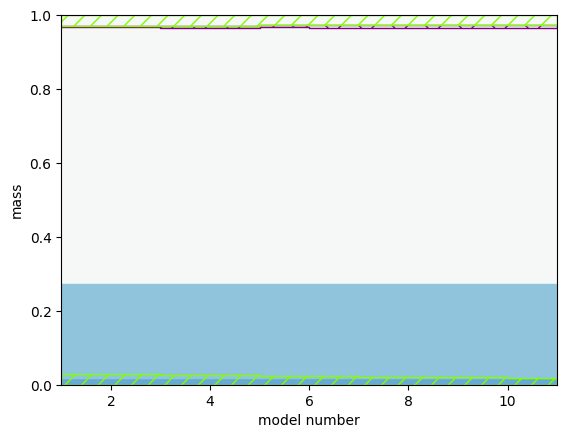

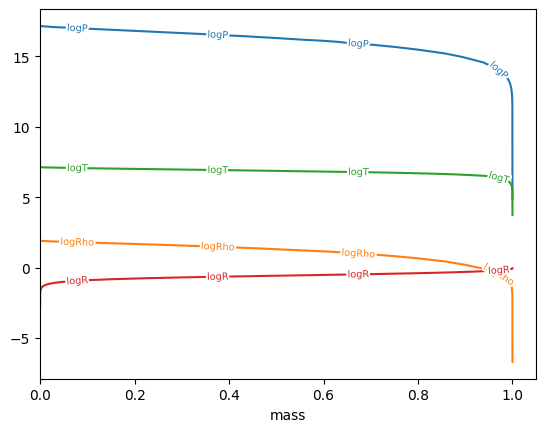

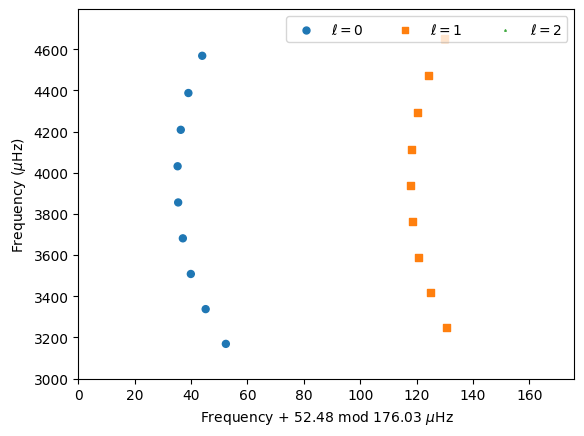

In [22]:
from wsssss.plotting import plotting as pl

hist = ld.History(f'{grid_dir}/m1.000_fOV0.020/LOGS/history.data')
profs = ld.load_profs(hist)
gss = ld.load_gss(hist)

pl.make_kipp(hist)
pl.make_structural(profs[-1])
pl.make_echelle(gss[-1], hist)